# Lecture 10 (B09): Physics-informed neural networks

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §7.1-7.4 (PINN foundations), §7.5-7.9 (Economic PDEs (HJB, Black-Scholes))  
**Notebook role:** core  
**Original live-course source:** `lectures/day6/code/02_ODE_PINN_SoftVsHardBCs.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Soft vs. Hard Boundary Conditions in PINNs

*Companion notebook to **Day 6 — PINNs and Continuous-Time Heterogeneous Agents** (Chapters 7–8 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

Physics-Informed Neural Networks (PINNs) embed differential equations into the training loss so that the
network learns a solution that satisfies the governing PDE. A key design choice is **how boundary conditions are enforced**.

This notebook compares two strategies on a simple second-order ODE:

$$y''(x) = -1, \quad x \in (0,1), \qquad y(0)=1,\; y(1)=2.$$

The analytical solution is $y(x) = -\tfrac{1}{2}x^2 + \tfrac{3}{2}x + 1$.

| Approach | Idea | Pros | Cons |
|----------|------|------|------|
| **Soft (penalty)** | Add BC residuals to the loss with a penalty weight | Simple to implement; works for any BC type | BCs only approximately satisfied; weight tuning needed |
| **Hard (trial solution)** | Construct an ansatz $\hat{y}(x)=A(x)+B(x)\,N(x;\theta)$ that satisfies BCs exactly by design | BCs satisfied exactly; loss has fewer terms | Requires problem-specific construction of $A$ and $B$ |

> **In-class notebook** (Day 6, Block 1 \u2014 PINNs Foundations & Economic Applications, 75 min)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13

# torch.compile is wrapped on per-batch steps below for JIT speedups.
# PINN-style losses use torch.autograd.grad with create_graph=True (double
# backward), which the default aot_autograd backend in PyTorch 2.x does not
# yet support. We use backend='eager' and allow dynamo to fall back to eager
# Python whenever it cannot trace a sub-call (e.g. clip_grad_norm_).
import torch._dynamo
torch._dynamo.config.suppress_errors = True


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(0)

Using device: cpu


## Part 1: Soft Boundary Conditions

In the **soft** (penalty) approach we train a raw neural network $N(x;\theta)$ and define the loss as

$$\mathcal{L} = \underbrace{\frac{1}{N_r}\sum_{i=1}^{N_r}\bigl(y''(x_i)+1\bigr)^2}_{\text{PDE residual}}
  + \underbrace{\bigl(y(0)-1\bigr)^2 + \bigl(y(1)-2\bigr)^2}_{\text{BC penalty}}.$$

The boundary conditions are only satisfied **approximately**, to the extent that the optimiser can
drive the penalty terms to zero alongside the PDE residual.

In [3]:
class ODE_Net(nn.Module):
    """Fully-connected network: 1 -> 20 -> 20 -> 1 with Tanh activations."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)

In [4]:
def residual_soft(model, x):
    """Compute the PDE residual y''(x) + 1 for the soft-BC model.

    Uses two rounds of torch.autograd.grad to obtain the second derivative.
    """
    x.requires_grad_(True)
    y = model(x)
    dy = torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]
    d2y = torch.autograd.grad(
        dy, x, grad_outputs=torch.ones_like(dy), create_graph=True
    )[0]
    return d2y + 1.0  # should be zero

In [5]:
# ---- Training: Soft BCs ----
torch.manual_seed(0)

model_soft = ODE_Net().to(device)
optimizer_soft = optim.Adam(model_soft.parameters(), lr=1e-3)

n_epochs_soft = 20000
n_colloc = 50  # interior collocation points

# Fixed collocation grid
x_interior = torch.linspace(0.01, 0.99, n_colloc, device=device).reshape(-1, 1)
x_bc0 = torch.zeros(1, 1, device=device)
x_bc1 = torch.ones(1, 1, device=device)


def train_step_soft(x_int):
    optimizer_soft.zero_grad()
    res = residual_soft(model_soft, x_int)
    loss_pde = torch.mean(res ** 2)
    loss_bc0 = (model_soft(x_bc0) - 1.0) ** 2
    loss_bc1 = (model_soft(x_bc1) - 2.0) ** 2
    loss = loss_pde + loss_bc0 + loss_bc1
    loss.backward()
    optimizer_soft.step()
    return loss, loss_pde, loss_bc0, loss_bc1


# torch.compile per-batch step (backend="eager", fullgraph=False:
# residual uses torch.autograd.grad with create_graph=True for second derivatives,
# which the default aot_autograd backend in PyTorch 2.x does not yet support.)
train_step_soft = torch.compile(train_step_soft, fullgraph=False, backend="eager")

for epoch in range(1, n_epochs_soft + 1):
    loss, loss_pde, loss_bc0, loss_bc1 = train_step_soft(x_interior)

    if epoch % 2000 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d}/{n_epochs_soft}  "
            f"Loss = {loss.item():.3e}  "
            f"(PDE {loss_pde.item():.3e}, "
            f"BC0 {loss_bc0.item():.3e}, "
            f"BC1 {loss_bc1.item():.3e})"
        )

print("\nSoft-BC training complete.")


Epoch     1/20000  Loss = 7.521e+00  (PDE 9.453e-01, BC0 1.420e+00, BC1 5.156e+00)


Epoch  2000/20000  Loss = 1.063e-04  (PDE 1.063e-04, BC0 2.652e-09, BC1 1.682e-09)


Epoch  4000/20000  Loss = 8.057e-05  (PDE 8.057e-05, BC0 5.375e-11, BC1 3.581e-09)


Epoch  6000/20000  Loss = 4.781e-05  (PDE 4.781e-05, BC0 2.274e-11, BC1 1.331e-09)


Epoch  8000/20000  Loss = 1.767e-05  (PDE 1.767e-05, BC0 3.696e-11, BC1 3.283e-10)


...

Epoch 12000/20000  Loss = 2.083e-07  (PDE 2.083e-07, BC0 5.684e-14, BC1 5.116e-13)


Epoch 14000/20000  Loss = 6.973e-07  (PDE 2.175e-07, BC0 2.478e-07, BC1 2.319e-07)


Epoch 16000/20000  Loss = 1.926e-06  (PDE 3.843e-07, BC0 7.338e-07, BC1 8.079e-07)


Epoch 18000/20000  Loss = 1.757e-07  (PDE 1.731e-07, BC0 1.283e-09, BC1 1.331e-09)


Epoch 20000/20000  Loss = 1.649e-07  (PDE 1.639e-07, BC0 4.811e-10, BC1 5.515e-10)

Soft-BC training complete.


In [6]:
# ---- Evaluate soft model ----
x_test = torch.linspace(0, 1, 300, device=device).reshape(-1, 1)

with torch.no_grad():
    y_soft = model_soft(x_test).cpu().numpy().flatten()

x_np = x_test.cpu().numpy().flatten()
y_exact = -0.5 * x_np ** 2 + 1.5 * x_np + 1.0

print(f"Soft-BC  max |error|: {np.max(np.abs(y_soft - y_exact)):.6e}")

Soft-BC  max |error|: 2.849102e-05


## Part 2: Hard Boundary Conditions

In the **hard** (trial-solution) approach we never ask the optimiser to enforce boundary conditions.
Instead we construct an ansatz (trial solution) that satisfies them **by construction**:

$$\hat{y}(x) = A(x) + B(x)\,N(x;\theta),$$

where

* $A(x) = 1 + x$ satisfies both BCs: $A(0)=1$, $A(1)=2$,
* $B(x) = x(1-x)$ vanishes at the boundaries: $B(0)=B(1)=0$,
* $N(x;\theta)$ is a free neural network.

No matter what $N$ outputs, $\hat{y}$ always satisfies $\hat{y}(0)=1$ and $\hat{y}(1)=2$.
The loss therefore contains **only** the PDE residual.

In [7]:
class Net(nn.Module):
    """Fully-connected network: 1 -> 20 -> 20 -> 1 with Tanh activations."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)


def A(x):
    """Particular solution satisfying the BCs: A(0)=1, A(1)=2."""
    return 1.0 + x


def B(x):
    """Distance function vanishing at both boundaries: B(0)=B(1)=0."""
    return x * (1.0 - x)


def y_trial(model, x):
    """Hard-BC trial solution: y_hat = A(x) + B(x) * N(x; theta)."""
    return A(x) + B(x) * model(x)


def residual_hard(model, x):
    """Compute the PDE residual y_hat''(x) + 1 for the hard-BC model."""
    x.requires_grad_(True)
    y = y_trial(model, x)
    dy = torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True
    )[0]
    d2y = torch.autograd.grad(
        dy, x, grad_outputs=torch.ones_like(dy), create_graph=True
    )[0]
    return d2y + 1.0  # should be zero

In [8]:
# ---- Training: Hard BCs ----
torch.manual_seed(0)

model_hard = Net().to(device)
optimizer_hard = optim.Adam(model_hard.parameters(), lr=1e-3)

n_epochs_hard = 20000
n_colloc_hard = 50

# Initial collocation points (will be resampled)
x_colloc = torch.rand(n_colloc_hard, 1, device=device)


def train_step_hard(x_col):
    optimizer_hard.zero_grad()
    res = residual_hard(model_hard, x_col)
    loss = torch.mean(res ** 2)
    loss.backward()
    optimizer_hard.step()
    return loss


# torch.compile per-batch step (backend="eager", fullgraph=False:
# residual uses torch.autograd.grad with create_graph=True for second derivatives,
# which the default aot_autograd backend in PyTorch 2.x does not yet support.)
train_step_hard = torch.compile(train_step_hard, fullgraph=False, backend="eager")

for epoch in range(1, n_epochs_hard + 1):
    if epoch % 100 == 1:
        x_colloc = torch.rand(n_colloc_hard, 1, device=device)
    loss = train_step_hard(x_colloc)

    if epoch % 2000 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d}/{n_epochs_hard}  Loss = {loss.item():.3e}")

print("\nHard-BC training complete.")


Epoch     1/20000  Loss = 2.119e+00


Epoch  2000/20000  Loss = 9.403e-07


Epoch  4000/20000  Loss = 8.985e-07


Epoch  6000/20000  Loss = 6.032e-07


Epoch  8000/20000  Loss = 3.768e-07


...

Epoch 12000/20000  Loss = 1.515e-07


Epoch 14000/20000  Loss = 1.071e-07


Epoch 16000/20000  Loss = 4.310e-08


Epoch 18000/20000  Loss = 1.680e-07


Epoch 20000/20000  Loss = 3.061e-08

Hard-BC training complete.


In [9]:
# ---- Evaluate hard model ----
x_test_hard = torch.linspace(0, 1, 300, device=device).reshape(-1, 1)

with torch.no_grad():
    y_hard = y_trial(model_hard, x_test_hard).cpu().numpy().flatten()

x_np_hard = x_test_hard.cpu().numpy().flatten()
y_exact_hard = -0.5 * x_np_hard ** 2 + 1.5 * x_np_hard + 1.0

print(f"Hard-BC  max |error|: {np.max(np.abs(y_hard - y_exact_hard)):.6e}")

Hard-BC  max |error|: 4.291534e-06


## Comparison

We now plot both PINN solutions against the analytical reference and compare their
absolute errors across the domain.

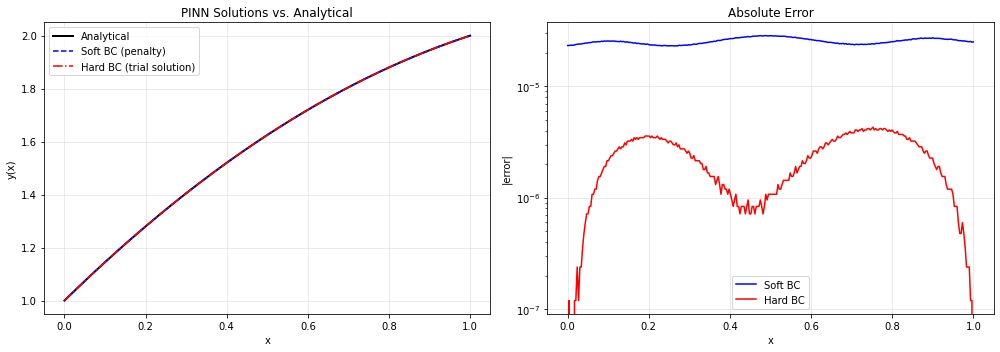

Soft-BC  max |error|: 2.849102e-05
Hard-BC  max |error|: 4.291534e-06


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: Solutions ---
ax = axes[0]
ax.plot(x_np, y_exact, "k-", linewidth=2, label="Analytical")
ax.plot(x_np, y_soft, "b--", linewidth=1.5, label="Soft BC (penalty)")
ax.plot(x_np_hard, y_hard, "r-.", linewidth=1.5, label="Hard BC (trial solution)")
ax.set_xlabel("x")
ax.set_ylabel("y(x)")
ax.set_title("PINN Solutions vs. Analytical")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right panel: Absolute errors ---
ax = axes[1]
ax.semilogy(x_np, np.abs(y_soft - y_exact), "b-", linewidth=1.5, label="Soft BC")
ax.semilogy(
    x_np_hard, np.abs(y_hard - y_exact_hard), "r-", linewidth=1.5, label="Hard BC"
)
ax.set_xlabel("x")
ax.set_ylabel("|error|")
ax.set_title("Absolute Error")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Summary statistics ----
print(f"Soft-BC  max |error|: {np.max(np.abs(y_soft - y_exact)):.6e}")
print(f"Hard-BC  max |error|: {np.max(np.abs(y_hard - y_exact_hard)):.6e}")